In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
from datetime import timedelta

In [2]:
trash_data = gpd.read_file('./data/trash_hauler_report.csv')
nashville = gpd.read_file('./data/nashville_zip_codes.geojson')
#trash_data

In [3]:
# Finding unique values for the Request column 
pd.unique(trash_data['Request'])

array(['Trash - Backdoor', 'Trash - Curbside/Alley Missed Pickup',
       'Trash Collection Complaint', 'Damage to Property'], dtype=object)

In [4]:
backdoor = trash_data.loc[trash_data['Request'] == 'Trash - Backdoor']
backdoor.shape

(2629, 11)

In [5]:
cs_alley = trash_data.loc[trash_data['Request'] == 'Trash - Curbside/Alley Missed Pickup']
cs_alley.shape

(15028, 11)

In [6]:
complaint = trash_data.loc[trash_data['Request'] == 'Trash Collection Complaint']
#complaint

In [7]:
contains_miss = complaint['Description'].str.contains('miss', case = 'False', na ='False')
#contains_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_40216\3712832755.py:1: FutureWarning: Allowing a non-bool 'na' in obj.str.contains is deprecated and will raise in a future version.
  contains_miss = complaint['Description'].str.contains('miss', case = 'False', na ='False')


In [8]:
miss_complaint = complaint[contains_miss]
miss_complaint.shape

(453, 11)

In [9]:
miss_all = pd.concat([backdoor, cs_alley, miss_complaint], ignore_index = 'True')

In [10]:
miss_all['Short Address'] = miss_all['Incident Address'].str.split(',', n=1).str[0]
miss_all['Short Address'] = miss_all['Short Address'].str.lower()
#miss_all

In [11]:
miss_count_by_address = miss_all['Short Address'].value_counts().reset_index(name='Missed Pickups')
#miss_count_by_address = miss_count_by_address.to_frame()
miss_count_by_address

,Short Address,Missed Pickups
0,110 george l davis blvd,27
1,12546 old hickory blvd,21
2,5135 hickory hollow pkwy,20
3,802 crescent rd,19
4,1584 bell rd,19
...,...,...
11305,739 rodney dr,1
11306,3805 elkins ave,1
11307,800 old hickory blvd,1
11308,631 blackstone ave,1


In [12]:
frequently_missed = miss_count_by_address.loc[miss_count_by_address['Missed Pickups'] > 1]
#frequently_missed

In [13]:
frequently_missed['Fine Amount'] = (frequently_missed['Missed Pickups'] - 1) * 200
#frequently_missed

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_40216\586745988.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frequently_missed['Fine Amount'] = (frequently_missed['Missed Pickups'] - 1) * 200


In [14]:
total_damages = frequently_missed['Fine Amount'].sum()
def currency_format(amount):
    return "${:,}".format(amount)
formatted_cost = currency_format(total_damages)
print(f"The total amount in damages is {formatted_cost}")

The total amount in damages is $1,360,000


<h1>Other types of complaints</h1>

In [15]:
other_complaints = trash_data[~trash_data['Request Number'].isin(miss_all['Request Number'])].reset_index()
#other_complaints

<h1>Heat Maps</h1>

<h2>Missed Pick Ups</h2>

In [16]:
miss_by_zip = miss_all['Request Number'].groupby(miss_all['Zip Code']).count().reset_index()
#miss_by_zip

In [17]:
nashville.columns

Index(['OBJECTID', 'ZipCode', 'POName', 'GlobalID', 'geometry'], dtype='object')

In [18]:
miss_map = nashville.merge(miss_by_zip, how = 'left', left_on = 'ZipCode', right_on = 'Zip Code')
#miss_map

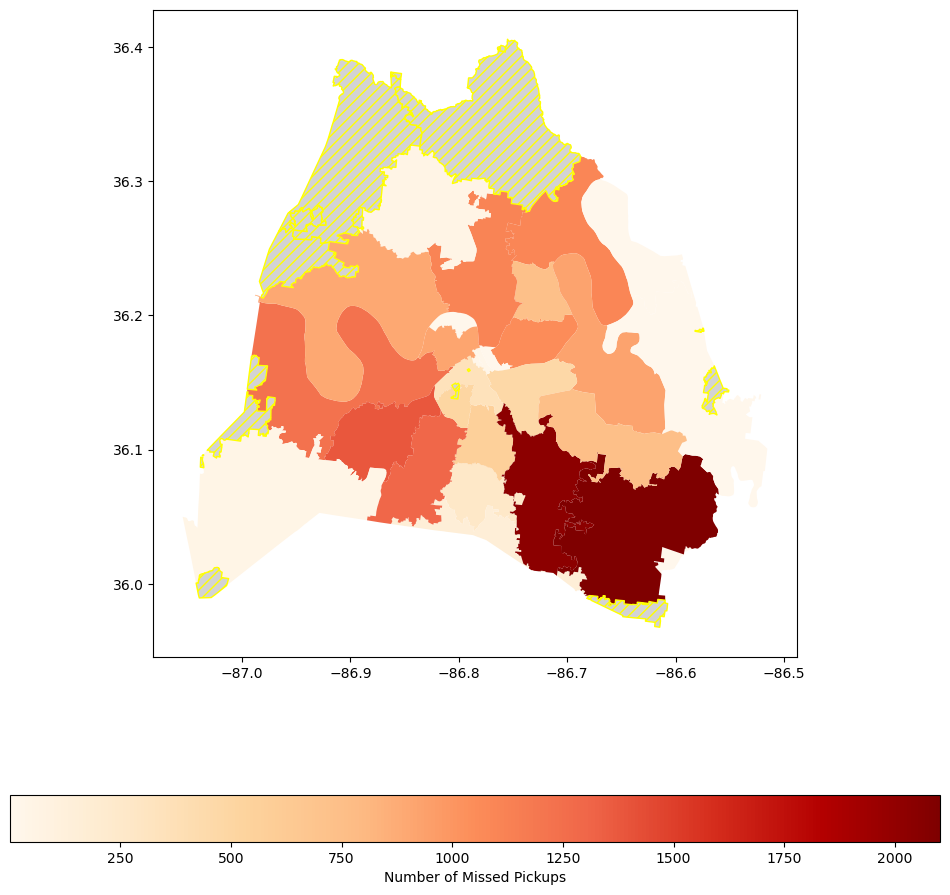

In [19]:
miss_map.plot(column = 'Request Number', 
              cmap = 'OrRd', 
              legend = True, 
              #scheme = "quantiles",
              figsize = (12, 12),
              legend_kwds={"label": "Number of Missed Pickups", "orientation": "horizontal"},
             missing_kwds = {"color": "lightgrey", "edgecolor": "yellow", "hatch": "///"})
fig = plt.gcf()
#fig.set_size_inches(12, 12)
plt.show()
#nashville.plot()

<h2>Total Fines</h2>

In [20]:
fine_by_zip = frequently_missed.merge(miss_all[['Zip Code', 'Short Address']], how = 'left', on = 'Short Address')
fine_by_zip = fine_by_zip.drop_duplicates()
fine_by_zip['Zip Code'].replace('', np.nan, inplace=True)
fine_by_zip.dropna(subset = ['Zip Code'], inplace = True)
fine_by_zip = fine_by_zip.groupby('Zip Code').sum('Fine Amount').reset_index()
#fine_by_zip

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_40216\622137585.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fine_by_zip['Zip Code'].replace('', np.nan, inplace=True)


In [21]:
fine_map = nashville.merge(fine_by_zip, how = 'left', left_on = 'ZipCode', right_on = 'Zip Code')
#fine_map = fine_map.groupby('ZipCode').sum('Fine Amount').reset_index()
fine_map = fine_map.sort_values(by = ['Fine Amount'])
#fine_map

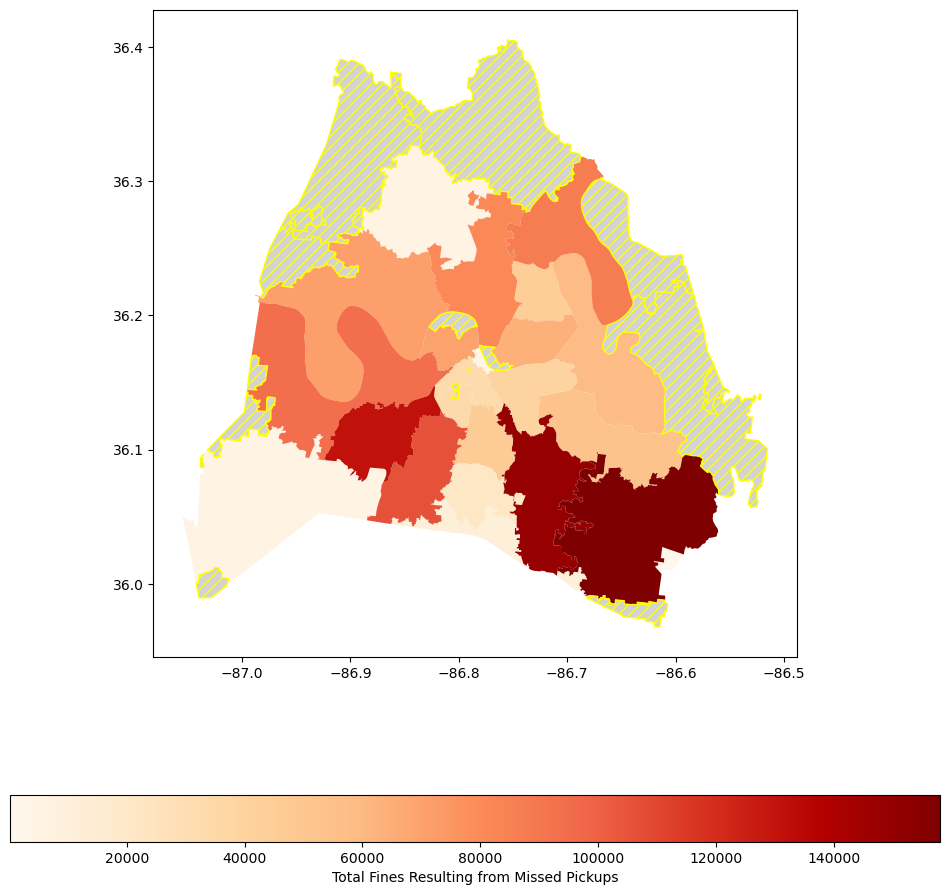

In [22]:
fine_map.plot(column = 'Fine Amount', 
              cmap = 'OrRd', 
              legend = True, 
              #scheme = "quantiles",
              figsize = (12, 12),
              legend_kwds={"label": "Total Fines Resulting from Missed Pickups", "orientation": "horizontal"},
              missing_kwds = {"color": "lightgrey", "edgecolor": "yellow", "hatch": "///"})
fig = plt.gcf()
plt.show()

<h1>Investigating metro crews vs contractor performance</h1>

<h2>Metro Performance</h2>

In [23]:
metro = miss_all.loc[miss_all['Trash Hauler'].str.lower() == 'metro'].reset_index()
#metro

In [24]:
metro_miss_count = metro['Short Address'].value_counts().reset_index(name='Missed Pickups')

In [25]:
metro_freq_miss = metro_miss_count.loc[metro_miss_count['Missed Pickups'] > 1]
metro_freq_miss['Fine Amount'] = (metro_freq_miss['Missed Pickups'] - 1) * 200
#metro_freq_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_40216\3259311114.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metro_freq_miss['Fine Amount'] = (metro_freq_miss['Missed Pickups'] - 1) * 200


In [26]:
metro_damages = metro_freq_miss['Fine Amount'].sum()
metro_format = currency_format(metro_damages)
metro_format

'$215,800'

<h2>Red River Performance</h2>

In [27]:
trash_data['Trash Hauler'].unique()

array(['RED RIVER', 'WASTE IND', 'METRO', '', 'Metro'], dtype=object)

In [28]:
red_river = miss_all.loc[miss_all['Trash Hauler'] == 'RED RIVER'].reset_index()
#red_river

In [29]:
red_river_miss_count = red_river['Short Address'].value_counts().reset_index(name='Missed Pickups')

In [30]:
red_river_freq_miss = red_river_miss_count.loc[red_river_miss_count['Missed Pickups'] > 1]
red_river_freq_miss['Fine Amount'] = (red_river_freq_miss['Missed Pickups'] - 1) * 200
#red_river_freq_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_40216\3247070420.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  red_river_freq_miss['Fine Amount'] = (red_river_freq_miss['Missed Pickups'] - 1) * 200


In [31]:
red_river_damages = red_river_freq_miss['Fine Amount'].sum()
red_river_format = currency_format(red_river_damages)
red_river_format

'$970,000'

<h2>Waste Ind Performance</h2>

In [32]:
waste_ind = miss_all.loc[miss_all['Trash Hauler'] == 'WASTE IND'].reset_index()
#waste_ind

In [33]:
waste_ind_miss_count = waste_ind['Short Address'].value_counts().reset_index(name='Missed Pickups')

In [34]:
waste_ind_freq_miss = waste_ind_miss_count.loc[waste_ind_miss_count['Missed Pickups'] > 1]
waste_ind_freq_miss['Fine Amount'] = (waste_ind_freq_miss['Missed Pickups'] - 1) * 200
#waste_ind_freq_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_40216\3342038832.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  waste_ind_freq_miss['Fine Amount'] = (waste_ind_freq_miss['Missed Pickups'] - 1) * 200


In [35]:
waste_ind_damages = waste_ind_freq_miss['Fine Amount'].sum()
waste_ind_format = currency_format(waste_ind_damages)
waste_ind_format

'$78,200'

<h1>Finding total missed pickups by route</h1>

In [36]:
miss_by_route = miss_all['Request Number'].groupby(miss_all['Trash Route']).count().reset_index()
miss_by_route.sort_values(by = 'Request Number').reset_index()

,index,Trash Route,Request Number
0,23,1502S,1
1,60,2505S,2
2,106,4201S,2
3,78,3303S,2
4,135,4504S,3
...,...,...,...
168,7,1301,264
169,10,1303,268
170,75,3302,300
171,134,4504,329


In [37]:
miss_4504 = miss_all.loc[miss_all['Trash Route'] == '4504']
miss_4504 = miss_4504.reset_index()
miss_4504

,index,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Short Address
0,760,96247,09/10/18,Trash - Backdoor,backdoor miss,1434 EAGLE VIEW BLVD,37013,RED RIVER,4504,32,1778609.76060102,626045.740852287,1434 eagle view blvd
1,775,99381,09/14/18,Trash - Backdoor,backdoor miss,"5704 Mt View Rd, Nashville, TN 37013, United S...",37013,RED RIVER,4504,32,1782555.72848136,623307.411550531,5704 mt view rd
2,779,99677,09/17/18,Trash - Backdoor,Missed.,"1434 Eagle View Blvd, Nashville, TN 37013, Uni...",37013,RED RIVER,4504,32,1778611.21861018,626043.248469281,1434 eagle view blvd
3,1233,140008,02/08/19,Trash - Backdoor,This is second week my trash has not been pick...,"760 Bell Rd, Nashville, TN 37013, United States",37013,RED RIVER,4504,32,1778376.99894729,626745.600750423,760 bell rd
4,1562,158533,03/22/19,Trash - Backdoor,This is the second week my trash has not been ...,"760 Bell Rd, Nashville, TN 37013, United States",37013,RED RIVER,4504,32,1778376.99894729,626745.600750423,760 bell rd
...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,17949,176974,04/30/19,Trash Collection Complaint,customer stated that she asked a driver to pic...,"622 Pippin Dr, Nashville, TN 37013, United States",37013,RED RIVER,4504,28,1776269.31285879,629465.477006143,622 pippin dr
325,17966,191325,05/29/19,Trash Collection Complaint,"Trash/missed for 3 weeks in a row, curb {other...","5062 Mt View Rd, Nashville, TN 37013, United S...",37013,RED RIVER,4504,32,1771464.19952548,627670.401062367,5062 mt view rd
326,17969,193328,06/03/19,Trash Collection Complaint,customer stated that her trash is constantly m...,"1913 Terragon Ct, Nashville, TN 37013, United ...",37013,RED RIVER,4504,28,1770467.14090311,634953.994032796,1913 terragon ct
327,17990,205606,06/25/19,Trash Collection Complaint,Caller upset that he just continues to be miss...,"5135 Hickory Hollow Pkwy, Nashville, TN 37013,...",37013,RED RIVER,4504,32,1771717.29456211,625521.535038538,5135 hickory hollow pkwy


<h1>Bonus</h1>

For each address, if there are three or more missed pickups within a 180-day period, damages of $1500 will be charged. (A fine will be levied every time three unique missed pickup dates occur within a six-month period for a single address.)

In [38]:
miss_all.columns

Index(['Request Number', 'Date Opened', 'Request', 'Description',
       'Incident Address', 'Zip Code', 'Trash Hauler', 'Trash Route',
       'Council District', 'State Plan X', 'State Plan Y', 'Short Address'],
      dtype='object')

In [48]:
miss_all_sort = miss_all.sort_values(by = ['Short Address', 'Date Opened'])
miss_all_sort['Short Address'] = miss_all_sort['Short Address'].replace('', np.nan)
miss_all_sort = miss_all_sort.dropna(subset = ['Short Address'])

In [49]:
miss_three = miss_count_by_address.loc[miss_count_by_address['Missed Pickups'] > 2]
miss_three = miss_all_sort.loc[miss_all_sort['Short Address'].isin(miss_three['Short Address'])]
miss_three = miss_three[['Date Opened', 'Short Address']]
miss_three = miss_three.reset_index(drop = True)
miss_three

,Date Opened,Short Address
0,06/06/19,1000 2nd ave n
1,06/27/19,1000 2nd ave n
2,07/10/19,1000 2nd ave n
3,08/12/19,1000 trevino pl
4,08/19/19,1000 trevino pl
...,...,...
6213,06/13/19,granbery park dr
6214,06/27/19,granbery park dr
6215,07/18/19,tusculum rd
6216,08/01/19,tusculum rd


In [50]:
for index, row in miss_three.iterrows():
    print(f"Date: {row['Date Opened']}, Address: {row['Short Address']}")
    

Date: 06/06/19, Address: 1000 2nd ave n
Date: 06/27/19, Address: 1000 2nd ave n
Date: 07/10/19, Address: 1000 2nd ave n
Date: 08/12/19, Address: 1000 trevino pl
Date: 08/19/19, Address: 1000 trevino pl
Date: 10/28/19, Address: 1000 trevino pl
Date: 01/07/19, Address: 1002 40th ave n
Date: 03/20/19, Address: 1002 40th ave n
Date: 12/28/18, Address: 1002 40th ave n
Date: 01/29/19, Address: 1004 chateau valley ct
Date: 02/05/19, Address: 1004 chateau valley ct
Date: 12/26/18, Address: 1004 chateau valley ct
Date: 08/30/19, Address: 1004 trevino pl
Date: 09/13/19, Address: 1004 trevino pl
Date: 09/27/19, Address: 1004 trevino pl
Date: 06/26/19, Address: 1005 graybar ln
Date: 06/26/19, Address: 1005 graybar ln
Date: 10/31/19, Address: 1005 graybar ln
Date: 02/08/18, Address: 1005 noelton ave
Date: 02/12/18, Address: 1005 noelton ave
Date: 05/03/18, Address: 1005 noelton ave
Date: 05/09/18, Address: 1005 noelton ave
Date: 05/17/18, Address: 1005 noelton ave
Date: 06/27/19, Address: 1005 noel

In [52]:
miss_three['Date Opened'] = pd.to_datetime(miss_three['Date Opened'], format = "mixed")
miss_three['Date Shift'] = miss_three['Date Opened'].shift(2)
miss_three['Address Shift'] = miss_three['Short Address'].shift(2)
miss_three['Fine'] = False
miss_three

,Date Opened,Short Address,Date Shift,Address Shift,Fine
0,2019-06-06,1000 2nd ave n,NaT,None,False
1,2019-06-27,1000 2nd ave n,NaT,None,False
2,2019-07-10,1000 2nd ave n,2019-06-06,1000 2nd ave n,False
3,2019-08-12,1000 trevino pl,2019-06-27,1000 2nd ave n,False
4,2019-08-19,1000 trevino pl,2019-07-10,1000 2nd ave n,False
...,...,...,...,...,...
6213,2019-06-13,granbery park dr,2019-05-16,granbery park dr,False
6214,2019-06-27,granbery park dr,2019-06-06,granbery park dr,False
6215,2019-07-18,tusculum rd,2019-06-13,granbery park dr,False
6216,2019-08-01,tusculum rd,2019-06-27,granbery park dr,False


In [53]:
miss_window = pd.Timedelta(180, "D")

for index, row in miss_three.iterrows():
    if str(row['Short Address']) == str(row['Address Shift']) and row['Date Opened'] - row['Date Shift'] <= miss_window:
        miss_three.at[index, 'Fine'] = True

miss_three

,Date Opened,Short Address,Date Shift,Address Shift,Fine
0,2019-06-06,1000 2nd ave n,NaT,None,False
1,2019-06-27,1000 2nd ave n,NaT,None,False
2,2019-07-10,1000 2nd ave n,2019-06-06,1000 2nd ave n,True
3,2019-08-12,1000 trevino pl,2019-06-27,1000 2nd ave n,False
4,2019-08-19,1000 trevino pl,2019-07-10,1000 2nd ave n,False
...,...,...,...,...,...
6213,2019-06-13,granbery park dr,2019-05-16,granbery park dr,True
6214,2019-06-27,granbery park dr,2019-06-06,granbery park dr,True
6215,2019-07-18,tusculum rd,2019-06-13,granbery park dr,False
6216,2019-08-01,tusculum rd,2019-06-27,granbery park dr,False


In [54]:
num_fines = miss_three['Fine'].sum()
fine_amount = 1500
total_fines = '${:,.2f}'.format(num_fines * fine_amount)
print("The total amount of fines collected with this method is:", total_fines)

The total amount of fines collected with this method is: $4,324,500.00


The total amount of fines collected with this method is: $5,139,000.00